# Blackjack Random Baseline

## 实验目标

这个 notebook 不训练任何策略，也不使用强化学习算法。它的目标是先展示在 Blackjack 这种回合式决策环境里，如果完全随机地在 `hit` 和 `stick` 之间切换，最终结果通常会是什么样。这个 baseline 会作为后续 `Monte Carlo Control` notebook 的参照，用来说明仅靠随机决策几乎不可能形成稳定的要牌与停牌边界。


## 环境背景

Blackjack 是一个典型的回合式离散决策环境。智能体需要根据自己的点数、庄家的明牌以及是否持有 usable ace，决定当前是继续要牌还是直接停牌。这个环境的难点不在于长链条控制，而在于每个动作都会直接改变爆牌风险和最终胜负概率。

它很适合说明为什么回合式采样方法有意义，因为一局结束后，整条决策轨迹的好坏会一次性体现到最终回报上。


## 方法说明

这里的方法就是纯随机动作采样：每个状态下直接从动作空间里随机选择 `hit` 或 `stick`，不维护价值估计，也不更新策略。它不是正式算法，但它能非常直观地说明这个环境为什么需要策略结构，而不是简单碰运气。


## 设备与并行说明

- 本实验默认使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不启用并行环境

原因是这个 notebook 主要做的是回合统计，不涉及神经网络训练。


In [1]:
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


In [2]:
ENV_ID = "Blackjack-v1"
NUM_EPISODES = 10000
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID)


## 参数选择说明

- `NUM_EPISODES = 10000`：让随机策略的统计结果足够稳定，同时保持执行速度足够快

Blackjack 是天然带回合边界的环境，不需要额外设置很大的步数上限。这里的重点是建立一个清晰的随机基线：随机决策通常会带来较高的失败率，也很难形成任何一致的策略边界。


In [3]:
episode_rewards = []
wins = []
draws = []
losses = []
player_sums = []

for episode in tqdm(range(NUM_EPISODES), desc="Random episodes"):
    state, info = env.reset(seed=SEED + episode)
    done = False

    while not done:
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, info = env.step(action)
        state = next_state
        done = terminated or truncated

    player_sum, dealer_card, usable_ace = state
    episode_rewards.append(float(reward))
    wins.append(int(reward > 0))
    draws.append(int(reward == 0))
    losses.append(int(reward < 0))
    player_sums.append(int(player_sum))

env.close()


Random episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

In [4]:
summary = pd.DataFrame(
    {
        "reward": episode_rewards,
        "win": wins,
        "draw": draws,
        "loss": losses,
        "terminal_player_sum": player_sums,
    }
)
summary.describe(include="all")


,reward,win,draw,loss,terminal_player_sum
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,-0.381000,0.28930,0.040400,0.670300,18.520400
std,0.902508,0.45346,0.196905,0.470128,5.942063
min,-1.000000,0.00000,0.000000,0.000000,4.000000
25%,-1.000000,0.00000,0.000000,0.000000,14.000000
50%,-1.000000,0.00000,0.000000,1.000000,19.000000
75%,1.000000,1.00000,0.000000,1.000000,23.000000
max,1.000000,1.00000,1.000000,1.000000,31.000000


In [5]:
win_rate = float(np.mean(wins))
draw_rate = float(np.mean(draws))
loss_rate = float(np.mean(losses))
avg_reward = float(np.mean(episode_rewards))

metrics = pd.DataFrame(
    {
        "metric": ["win_rate", "draw_rate", "loss_rate", "average_reward"],
        "value": [win_rate, draw_rate, loss_rate, avg_reward],
    }
)
metrics


,metric,value
0,win_rate,0.2893
1,draw_rate,0.0404
2,loss_rate,0.6703
3,average_reward,-0.3810


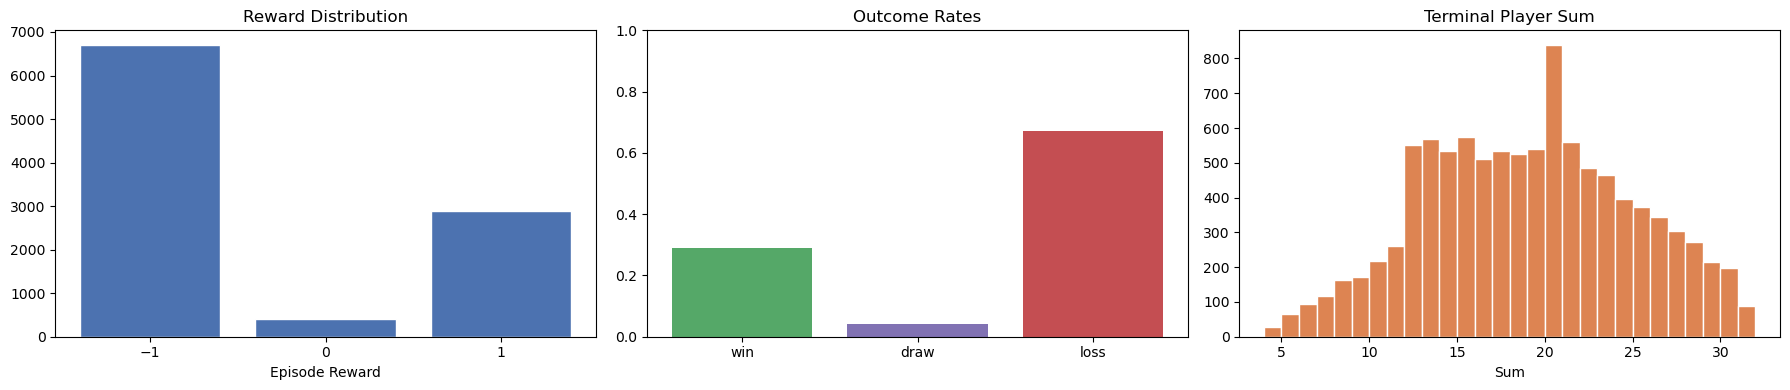

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(episode_rewards, bins=np.array([-1.5, -0.5, 0.5, 1.5]), color="#4c72b0", edgecolor="white", rwidth=0.8)
axes[0].set_title("Reward Distribution")
axes[0].set_xlabel("Episode Reward")
axes[0].set_xticks([-1, 0, 1])

axes[1].bar(["win", "draw", "loss"], [win_rate, draw_rate, loss_rate], color=["#55a868", "#8172b3", "#c44e52"])
axes[1].set_title("Outcome Rates")
axes[1].set_ylim(0, 1)

axes[2].hist(player_sums, bins=range(4, 33), color="#dd8452", edgecolor="white")
axes[2].set_title("Terminal Player Sum")
axes[2].set_xlabel("Sum")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "random_baseline_overview.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
metrics.to_csv(RESULTS_DIR / "random_baseline_metrics.csv", index=False)
summary.to_csv(RESULTS_DIR / "random_baseline_episode_summary.csv", index=False)

print(f"Win rate: {win_rate:.4f}")
print(f"Draw rate: {draw_rate:.4f}")
print(f"Loss rate: {loss_rate:.4f}")
print(f"Average reward: {avg_reward:.4f}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")


Win rate: 0.2893
Draw rate: 0.0404
Loss rate: 0.6703
Average reward: -0.3810
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/06-blackjack-monte-carlo-control/results


## 结果解读

随机策略在 Blackjack 里通常既没有稳定的停牌边界，也没有一致的风险控制能力。它会在很多明显不合理的点数下继续要牌，或者过早停牌，把结果交给运气。这说明这个环境更需要一套清晰的状态到动作映射，而不是随机选择。
